In [7]:
"""Quick visualization for CMA simulations. Run in your notebook."""

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import t as t_dist
from pyhealth.datasets import get_dataloader
from pyhealth.datasets.pmlb_meta_analysis_dataset import PMLBMetaAnalysisDataset
from pyhealth.models.conformal_meta_analysis_krr import (
    ConformalMetaAnalysisModel,
)
from pyhealth.tasks.conformal_meta_analysis import (
    ConformalMetaAnalysisTask,
)


In [8]:

# ---------------------------------------------------------------------
# HKSJ baseline
# ---------------------------------------------------------------------
def hksj_interval(Y, V, alpha=0.1):
    n = len(Y)
    nu = 0.0
    for _ in range(1000):
        w = 1.0 / (V + nu)
        ate = np.sum(w * Y) / np.sum(w)
        nu_new = max(
            0.0,
            np.sum(w ** 2 * ((Y - ate) ** 2 - V)) / np.sum(w ** 2)
            + 1.0 / np.sum(w),
        )
        if abs(nu_new - nu) < 1e-8:
            break
        nu = nu_new
    w = 1.0 / (V + nu)
    ate = np.sum(w * Y) / np.sum(w)
    var_ate = np.sum((Y - ate) ** 2 * w) / ((n - 1) * np.sum(w))
    half = t_dist.ppf(1 - alpha / 2, df=n - 1) * np.sqrt(nu + var_ate)
    return float(ate - half), float(ate + half)


# ---------------------------------------------------------------------
# Single-run harness: returns CMA / HKSJ / Prior widths & coverages.
# ---------------------------------------------------------------------
def run_one(
    n_train,
    prior_error,
    effect_noise,
    alpha=0.1,
    eta=0.0,
    seed=0,
    n_samples=2000,
):
    """Run one batch and return CMA, HKSJ, and fixed-prior results."""
    dataset = PMLBMetaAnalysisDataset(
        root=f"./data/pmlb_pe{prior_error}_en{effect_noise}_s{seed}",
        pmlb_dataset_name="1196_BNG_pharynx",
        synthesize_noise=True,
        prior_error=prior_error,
        effect_noise=effect_noise,
        seed=seed,
        n_samples=n_samples,
    )
    samples = dataset.set_task(ConformalMetaAnalysisTask())
    model = ConformalMetaAnalysisModel(
        dataset=samples, alpha=alpha, eta=eta, kernel_type="gaussian"
    )

    loader = get_dataloader(samples, batch_size=n_train, shuffle=True)
    batch = next(iter(loader))

    with torch.no_grad():
        out = model(**batch)

    lo = out["interval_lower"].cpu().numpy().ravel()
    hi = out["interval_upper"].cpu().numpy().ravel()
    u = batch["true_effect"].cpu().numpy().ravel()
    Y = batch["observed_effect"].cpu().numpy().ravel()
    V = batch["variance"].cpu().numpy().ravel()
    M = batch["prior_mean"].cpu().numpy().ravel()

    finite = np.isfinite(lo) & np.isfinite(hi)
    cma_width = (
        float(np.mean(hi[finite] - lo[finite])) if finite.any() else np.nan
    )
    cma_cov = float(np.mean((u >= lo) & (u <= hi)))

    hlo, hhi = hksj_interval(Y, V, alpha=alpha)
    hksj_width = hhi - hlo
    hksj_cov = float(np.mean((u >= hlo) & (u <= hhi)))

    # Fixed-prior: use M as a point predictor with a t-interval around
    # the residual standard deviation. Serves as the "no-learning"
    # baseline for Simulation 4.
    residuals = Y - M
    resid_sd = float(np.std(residuals))
    half = t_dist.ppf(1 - alpha / 2, df=n_train - 1) * resid_sd
    prior_width = 2 * half
    prior_cov = float(np.mean(np.abs(u - M) <= half))

    return {
        "cma_width": cma_width,
        "cma_cov": cma_cov,
        "hksj_width": hksj_width,
        "hksj_cov": hksj_cov,
        "prior_width": prior_width,
        "prior_cov": prior_cov,
    }


# ---------------------------------------------------------------------
# Simulation 1: Width vs n across prior quality
# ---------------------------------------------------------------------
def simulation_1(
    n_values=(20, 50, 100, 200), seeds=(0, 1), ylim=(0, 2500)
):
    priors = {"bad": 3.0, "okay": 0.9, "good": 0.2}
    results = {label: {n: [] for n in n_values} for label in priors}

    for label, pe in priors.items():
        for n in n_values:
            for s in seeds:
                r = run_one(n, pe, effect_noise=0.5, seed=s)
                results[label][n].append(r)
                print(
                    f"[Sim1] prior={label} n={n} seed={s} "
                    f"cma={r['cma_width']:.1f} hksj={r['hksj_width']:.1f}"
                )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, (label, pe) in zip(axes, priors.items()):
        n_vals = sorted(results[label].keys())
        cma = [
            np.nanmean([r["cma_width"] for r in results[label][n]])
            for n in n_vals
        ]
        hksj = [
            np.nanmean([r["hksj_width"] for r in results[label][n]])
            for n in n_vals
        ]
        ax.plot(n_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(n_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.set_xscale("log")
        ax.set_xlabel("n")
        ax.set_title(f"Simulation 1 ({label} prior)")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("interval width")
    plt.tight_layout()
    plt.savefig("simulation_1.png", dpi=150)
    plt.show()
    return results


# ---------------------------------------------------------------------
# Simulation 2: Coverage vs effect noise (CMA vs HKSJ)
# ---------------------------------------------------------------------
def simulation_2(
    noise_values=(0.0, 50.0, 100.0, 200.0, 400.0),
    n_values=(50, 200),
    seeds=(0, 1),
    alpha=0.05,
    ylim=(0.80, 1.02),
):
    results = {
        n: {noise: [] for noise in noise_values} for n in n_values
    }
    for n in n_values:
        for noise in noise_values:
            for s in seeds:
                r = run_one(
                    n, prior_error=0.2, effect_noise=noise,
                    alpha=alpha, seed=s,
                )
                results[n][noise].append(r)
                print(
                    f"[Sim2] n={n} noise={noise} seed={s} "
                    f"cma_cov={r['cma_cov']:.3f} hksj_cov={r['hksj_cov']:.3f}"
                )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        noise_vals = sorted(results[n].keys())
        cma = [
            np.nanmean([r["cma_cov"] for r in results[n][noise]])
            for noise in noise_vals
        ]
        hksj = [
            np.nanmean([r["hksj_cov"] for r in results[n][noise]])
            for noise in noise_vals
        ]
        ax.plot(noise_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(noise_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.axhline(1 - alpha, ls="--", color="black", alpha=0.5,
                   label=f"target {1 - alpha:.2f}")
        ax.set_xlabel("effect noise")
        size_label = "small n" if n < 100 else "large n"
        ax.set_title(f"Simulation 2 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("coverage")
    plt.tight_layout()
    plt.savefig("simulation_2.png", dpi=150)
    plt.show()
    return results


# ---------------------------------------------------------------------
# Simulation 3: Coverage with eta=0 vs eta>0
# ---------------------------------------------------------------------
def simulation_3(
    noise_values=(0.0, 100.0 , 500.0, 1000.0),
    n_values=(50, 200),
    seeds=(0, 1),
    alpha=0.05,
    ylim=(0.85, 1.02),
):
    # Compute the eta that targets ~2alpha confidence loss: eta = 2*inverfc(1/(2*(1-alpha)))^2
    # Here we just use a modest positive value (0.4015 from the paper).
    eta_values = {"eta=0": 0.0, "eta>0": 0.4015}

    results = {
        n: {name: {noise: [] for noise in noise_values}
            for name in eta_values}
        for n in n_values
    }
    for n in n_values:
        for name, eta in eta_values.items():
            for noise in noise_values:
                for s in seeds:
                    r = run_one(
                        n, prior_error=0.1, effect_noise=noise,
                        alpha=alpha, eta=eta, seed=s,
                    )
                    results[n][name][noise].append(r)
                    print(
                        f"[Sim3] n={n} {name} noise={noise} "
                        f"cov={r['cma_cov']:.3f}"
                    )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        noise_vals = sorted(noise_values)
        for name, color in [("eta=0", "salmon"), ("eta>0", "purple")]:
            covs = [
                np.nanmean([r["cma_cov"] for r in results[n][name][noise]])
                for noise in noise_vals
            ]
            ax.plot(noise_vals, covs, "-o", label=name, color=color)
        ax.axhline(1 - alpha, ls="--", color="black", alpha=0.5,
                   label=f"target {1 - alpha:.2f}")
        size_label = "small n" if n < 100 else "large n"
        ax.set_xlabel("effect noise")
        ax.set_title(f"Simulation 3 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("coverage")
    plt.tight_layout()
    plt.savefig("simulation_3.png", dpi=150)
    plt.show()
    return results


# ---------------------------------------------------------------------
# Simulation 4: Width comparison vs prior quality (CMA vs HKSJ vs Prior)
# ---------------------------------------------------------------------
def simulation_4(
    prior_values=(0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0),
    n_values=(16, 200),
    seeds=(0, 1),
    alpha=0.1,
    ylim=(0, 5000),
):
    results = {
        n: {pe: [] for pe in prior_values} for n in n_values
    }
    for n in n_values:
        for pe in prior_values:
            for s in seeds:
                r = run_one(
                    n, prior_error=pe, effect_noise=0.02,
                    alpha=alpha, seed=s,
                )
                results[n][pe].append(r)
                print(
                    f"[Sim4] n={n} pe={pe} seed={s} "
                    f"cma={r['cma_width']:.1f} "
                    f"hksj={r['hksj_width']:.1f} "
                    f"prior={r['prior_width']:.1f}"
                )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        pe_vals = sorted(results[n].keys())
        cma = [
            np.nanmean([r["cma_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        hksj = [
            np.nanmean([r["hksj_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        prior = [
            np.nanmean([r["prior_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        ax.plot(pe_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(pe_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.plot(pe_vals, prior, "-o", label="Prior", color="olive")
        size_label = "small n" if n < 100 else "large n"
        ax.set_xlabel("prior error")
        ax.set_title(f"Simulation 4 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("interval width")
    plt.tight_layout()
    plt.savefig("simulation_4.png", dpi=150)
    plt.show()
    return results

Simulation 1
No config path provided, using default config
Fetching PMLB dataset: 1196_BNG_pharynx
Saved PMLB metadata to ./data/pmlb_pe3.0_en0.5_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe3.0_en0.5_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\e805221c-5deb-50b3-94e2-5f570b69cd9d
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\e805221c-5deb-50b3-94e2-5f570b69cd9d\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\e805221c-5deb-50b3-94e2-5f570b69cd9d\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Applying task transformations on data with 1 workers...
No cached event datafram

  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['bytes']` data format.


100%|██████████| 2000/2000 [00:00<00:00, 2874.22it/s]

Worker 0 finished processing patients.
Fitting processors on the dataset...


...


  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['str', 'str', 'no_header_tensor:1', 'no_header_tensor:1', 'tensor', 'tensor', 'tensor']` data format.


100%|██████████| 2000/2000 [00:00<00:00, 9461.37it/s]

Worker 0 finished processing samples.
Cached processed samples to C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\f96eded7-b1e2-52ed-8d42-f463d41a7db5\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
[Sim1] prior=good n=20 seed=1 cma=533.4 hksj=1451.5
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en0.5_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8\tasks\ConformalMetaAna

[Sim1] prior=good n=50 seed=1 cma=505.5 hksj=1384.0
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en0.5_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\549ad6ca-411e-53ca-95c1-e33651d54df8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8eb

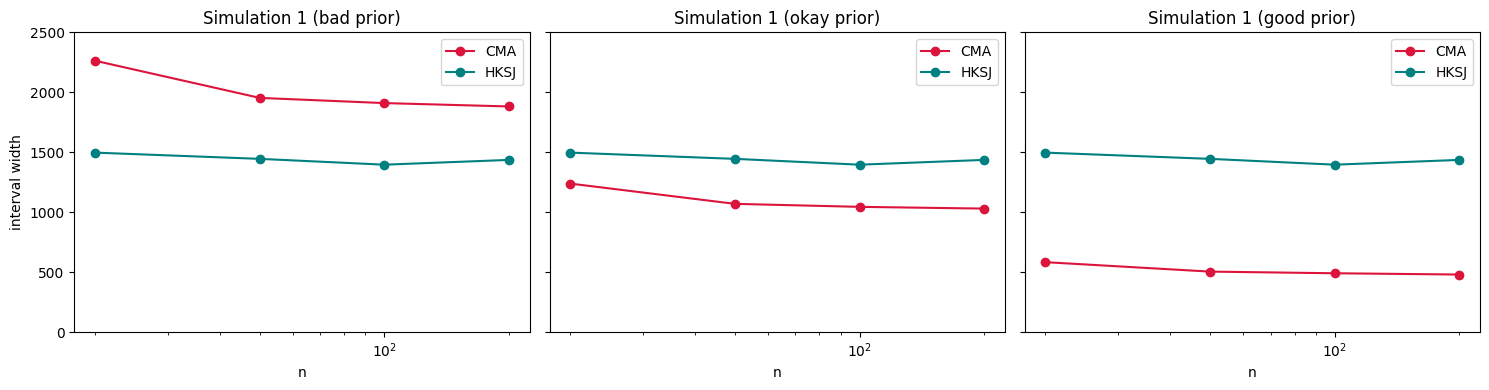

In [3]:
print("Simulation 1")
sim1 = simulation_1()

Simulation 2
No config path provided, using default config
Fetching PMLB dataset: 1196_BNG_pharynx
Saved PMLB metadata to ./data/pmlb_pe0.2_en0.0_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en0.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\ecccebb6-da1d-5286-8d55-fcc91ee15dee
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\ecccebb6-da1d-5286-8d55-fcc91ee15dee\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\ecccebb6-da1d-5286-8d55-fcc91ee15dee\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Applying task transformations on data with 1 workers...
No cached event datafram

  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['bytes']` data format.


100%|██████████| 2000/2000 [00:00<00:00, 2541.94it/s]

Worker 0 finished processing patients.
Fitting processors on the dataset...


...

[Sim2] n=200 noise=0.0 seed=0 cma_cov=0.950 hksj_cov=0.000
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en0.0_s1 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\5fd854ff-4788-5ee2-8a65-f892ec1e45cd
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\5fd854ff-4788-5ee2-8a65-f892ec1e45cd\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\5fd854ff-4788-5ee2-8a65-f892ec1e45cd\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\5fd854ff-4788-5ee2-8a65-f892ec1e45cd\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5

C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)


[Sim2] n=200 noise=0.0 seed=1 cma_cov=0.950 hksj_cov=0.000
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en50.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\75a3a4a8-b465-539b-8d98-cafae8f2ea30
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\75a3a4a8-b465-539b-8d98-cafae8f2ea30\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\75a3a4a8-b465-539b-8d98-cafae8f2ea30\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\75a3a4a8-b465-539b-8d98-cafae8f2ea30\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-

C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)


[Sim2] n=200 noise=50.0 seed=0 cma_cov=0.960 hksj_cov=0.950
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en50.0_s1 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\a92bd2d1-38f1-58f5-9933-b39cebb0aecf
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\a92bd2d1-38f1-58f5-9933-b39cebb0aecf\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\a92bd2d1-38f1-58f5-9933-b39cebb0aecf\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\a92bd2d1-38f1-58f5-9933-b39cebb0aecf\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c

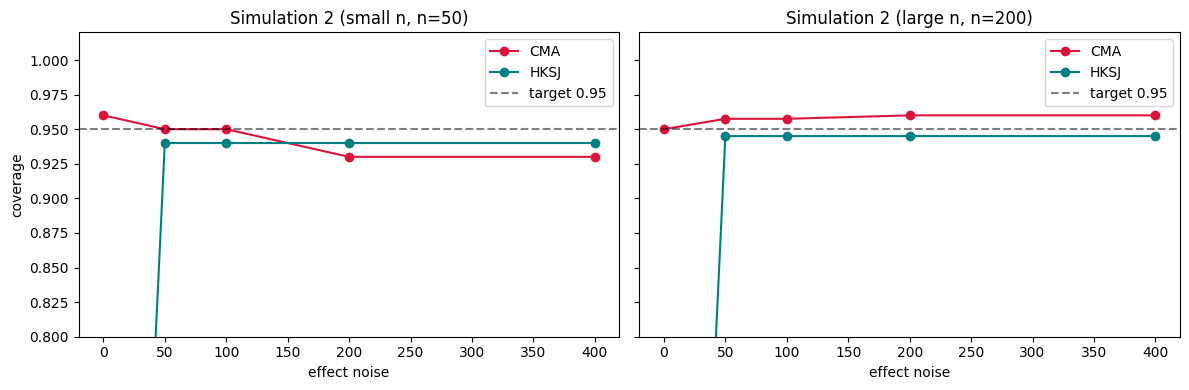

In [4]:
print("Simulation 2")
sim2 = simulation_2()

Simulation 3
No config path provided, using default config
Fetching PMLB dataset: 1196_BNG_pharynx
Saved PMLB metadata to ./data/pmlb_pe0.1_en0.0_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en0.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Applying task transformations on data with 1 workers...
No cached event datafram

  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['bytes']` data format.


100%|██████████| 2000/2000 [00:00<00:00, 2832.31it/s]

Worker 0 finished processing patients.
Fitting processors on the dataset...
Processing samples and saving to C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\dbc14fd7-741c-52eb-aa51-660909149833\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld...
Applying processors on data with 1 workers...
Detected Jupyter notebook environment, setting num_workers to 1
Single worker mode, processing sequentially
Worker 0 started processing 2000 samples. (0 to 2000)


...

[Sim3] n=200 eta=0 noise=100.0 cov=0.965
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en100.0_s1 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db0

C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)


[Sim3] n=200 eta>0 noise=0.0 cov=0.950
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en100.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\1df6a36a-c128-5678-b8d1-d4d387fa7c85\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db035

C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:8: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:9: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:18: RuntimeWarning: divide by zero encountered in divide
  w = 1.0 / (V + nu)
C:\Users\brett\AppData\Local\Temp\ipykernel_14056\1323635509.py:19: RuntimeWarning: invalid value encountered in scalar divide
  ate = np.sum(w * Y) / np.sum(w)


[Sim3] n=200 eta>0 noise=100.0 cov=0.965
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en100.0_s1 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\58fddf82-a84d-5fff-87bb-241ca19599e8\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db0

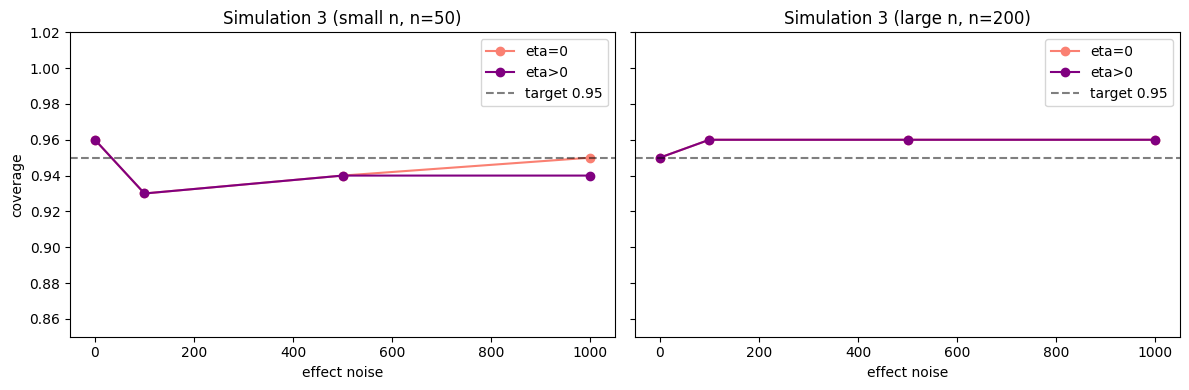

In [5]:
print("Simulation 3")
sim3 = simulation_3()

Simulation 4
No config path provided, using default config
Fetching PMLB dataset: 1196_BNG_pharynx
Saved PMLB metadata to ./data/pmlb_pe0.0_en0.02_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.0_en0.02_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Applying task transformations on data with 1 workers...
No cached event datafr

  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['bytes']` data format.


100%|██████████| 2000/2000 [00:00<00:00, 2682.34it/s]

Worker 0 finished processing patients.
Fitting processors on the dataset...


...

  0%|          | 0/2000 [00:00<?, ?it/s]

Rank 0 inferred the following `['str', 'str', 'no_header_tensor:1', 'no_header_tensor:1', 'tensor', 'tensor', 'tensor']` data format.


100%|██████████| 2000/2000 [00:00<00:00, 7097.48it/s]

Worker 0 finished processing samples.
Cached processed samples to C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\28e65f05-eb35-57d0-b8fe-124708bd6231\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld


[Sim4] n=16 pe=6.0 seed=1 cma=2603.0 hksj=1270.1 prior=1704.0
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.0_en0.02_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e3c-5b16-8ebb-fb57db03537a\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_6e7d0b7e-5e

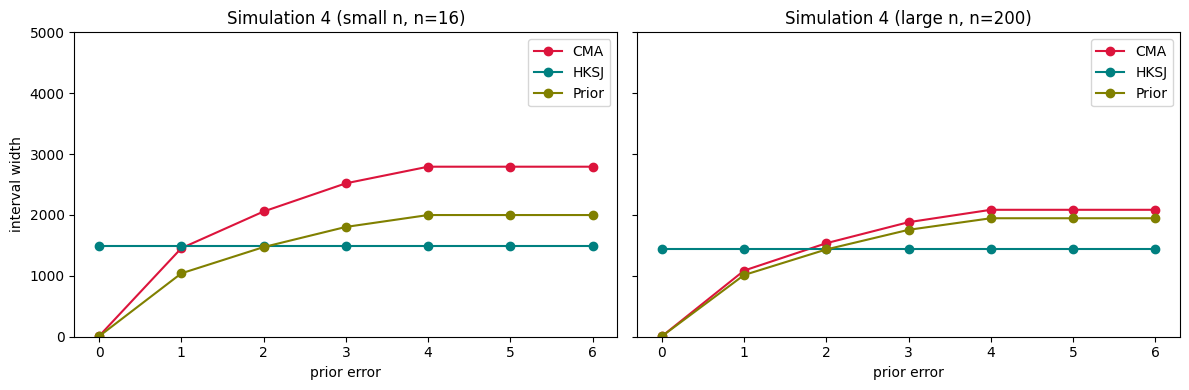

In [6]:
print("Simulation 4")
sim4 = simulation_4()

In [9]:
"""Ablation table: encoder architecture vs CMA interval width.

Trains different encoder architectures on untrusted amiodarone
trials, uses each to predict M values for trusted trials, and
reports the resulting CMA interval widths.
"""
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from pyhealth.datasets.amiodarone_trial_dataset import AmiodaroneTrialDataset
from pyhealth.models.cma_prior_encoder import CMAPriorEncoder
from pyhealth.models.conformal_meta_analysis_krr import (
    ConformalMetaAnalysisModel,
)
from pyhealth.tasks.conformal_meta_analysis import (
    ConformalMetaAnalysisTask,
)


FEATURE_COLUMNS = [
    "amiodarone_total_24h_mg", "comparison_intensity",
    "af_duration_gt_48h", "outcome_time_gt_48h",
    "mean_age", "mean_la_size",
    "fraction_male", "fraction_cv_disease", "followup_fraction",
    "adequate_concealment", "masked_patients",
    "masked_caregiver", "masked_assessor",
]

ENCODER_CONFIGS = [
    {"name": "Shallow",  "hidden_dims": [32],            "embed_dim": 8},
    {"name": "Medium",   "hidden_dims": [64, 32],        "embed_dim": 16},
    {"name": "Deep",     "hidden_dims": [128, 64, 32],   "embed_dim": 16},
    {"name": "Wide",     "hidden_dims": [256, 128],      "embed_dim": 32},
]


def collect_batch(sample_dataset):
    """Stack all samples in a SampleDataset into a single batch dict."""
    samples = list(sample_dataset)
    batch = {}
    for key in samples[0]:
        vals = [s[key] for s in samples]
        if isinstance(vals[0], torch.Tensor):
            batch[key] = torch.stack(vals).float()
        else:
            try:
                batch[key] = torch.tensor(
                    [float(v) for v in vals], dtype=torch.float32
                ).unsqueeze(-1)
            except (TypeError, ValueError):
                batch[key] = vals
    return batch


def train_encoder(encoder, features, targets, epochs=300, lr=1e-3):
    """Train the encoder with MSE loss on a fixed batch."""
    opt = optim.Adam(encoder.parameters(), lr=lr)
    targets = targets.view(-1, 1).float()
    encoder.train()
    for _ in range(epochs):
        opt.zero_grad()
        out = encoder(features=features, true_effect=targets)
        out["loss"].backward()
        opt.step()
    encoder.eval()
    return encoder


def run_ablation(dataset_root="./data/amiodarone", alpha=0.05, seed=0):
    """Return a DataFrame with one row per encoder architecture."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    dataset = AmiodaroneTrialDataset(root=dataset_root)

    # Untrusted trials for encoder training
    task_u = ConformalMetaAnalysisTask(
        target_column="log_relative_risk",
        feature_columns=FEATURE_COLUMNS,
        split_column="split", split_value="untrusted",
    )
    untrusted = dataset.set_task(task_u)
    u_batch = collect_batch(untrusted)

    # Trusted trials for CMA
    task_t = ConformalMetaAnalysisTask(
        target_column="log_relative_risk",
        feature_columns=FEATURE_COLUMNS,
        split_column="split", split_value="trusted",
        observed_column="log_relative_risk",
        variance_column="variance",
    )
    trusted = dataset.set_task(task_t)
    t_batch = collect_batch(trusted)

    rows = []
    for cfg in ENCODER_CONFIGS:
        encoder = CMAPriorEncoder(
            dataset=untrusted,
            hidden_dims=cfg["hidden_dims"],
            embed_dim=cfg["embed_dim"],
        )
        train_encoder(
            encoder,
            features=u_batch["features"],
            targets=u_batch["true_effect"],
        )

        # Predict M for trusted trials
        M = encoder.predict_prior_mean(t_batch["features"])
        t_batch_with_prior = dict(t_batch)
        t_batch_with_prior["prior_mean"] = M.unsqueeze(-1)

        # Run CMA
        cma = ConformalMetaAnalysisModel(dataset=trusted, alpha=alpha)
        with torch.no_grad():
            out = cma(**t_batch_with_prior)

        lo = out["interval_lower"].cpu().numpy().ravel()
        hi = out["interval_upper"].cpu().numpy().ravel()
        u_true = t_batch["true_effect"].cpu().numpy().ravel()

        finite = np.isfinite(lo) & np.isfinite(hi)
        width = float(np.mean(hi[finite] - lo[finite])) if finite.any() else np.nan
        coverage = float(np.mean((u_true >= lo) & (u_true <= hi)))

        # Prior quality measure
        mse_prior = float(
            torch.mean((M - t_batch["true_effect"].squeeze(-1)) ** 2)
        )


        rows.append({
            "Architecture": cfg["name"],
            "Hidden Dims": str(cfg["hidden_dims"]),
            "Embed Dim": cfg["embed_dim"],
            "Prior MSE": round(mse_prior, 4),
            "CMA Width": round(width, 4),
            "CMA Coverage": round(coverage, 3),
        })

    Y_trusted = t_batch["observed_effect"].cpu().numpy().ravel()
    V_trusted = t_batch["variance"].cpu().numpy().ravel()
    u_trusted = t_batch["true_effect"].cpu().numpy().ravel()
    hlo, hhi = hksj_interval(Y_trusted, V_trusted, alpha=alpha)
    hksj_coverage = float(np.mean((u_trusted >= hlo) & (u_trusted <= hhi)))
    rows.append({
    "Architecture": "HKSJ (baseline)",
    "Hidden Dims": "—",
    "Embed Dim": 0,
    "Prior MSE": np.nan,
    "CMA Width": round(hhi - hlo, 4),
    "CMA Coverage": round(hksj_coverage, 3),
    })

    return pd.DataFrame(rows)


if __name__ == "__main__":
    results = run_ablation(alpha = 0.1)
    print("\nEncoder Architecture Ablation Results")
    print("=" * 75)
    print(results.to_string(index=False))

No config path provided, using default config
Initializing amiodarone_trials dataset from ./data/amiodarone (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371
Setting task ConformalMetaAnalysisTask for amiodarone_trials base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371\tasks\ConformalMetaAnalysisTask_c067234c-231c-537b-aeb0-9f312dfeffcc\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371\tasks\ConformalMetaAnalysisTask_c067234c-231c-537b-aeb0-9f312dfeffcc\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371\tasks\ConformalMetaAnalysisTask_c067234c-231c-537b-aeb0-9f312dfeffcc\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipp